# MVP — Análise de Dados e Boas Práticas

**Nome:** Fabíola Dias Carvalho

**Matrícula:** 4052023001431

**Dataset:** [Kaggle - Diabetes 130-US Hospitals (1999–2008)](https://raw.githubusercontent.com/diasfabi7-prog/Analise-de-Dados-PUC-MVP/main/diabetic_data.csv)  

**Repositório GitHub:** [https://github.com/diasfabi7-prog/Analise-de-Dados-PUC-MVP](https://github.com/diasfabi7-prog/Analise-de-Dados-PUC-MVP)  

**Objetivo:** Prever a readmissão hospitalar de pacientes diabéticos com base em dados clínicos coletados em 130 hospitais americanos entre 1999 e 2008.


# Descrição do Problema

O dataset **Diabetes 130-US Hospitals (1999–2008)** contém dados clínicos de pacientes diabéticos internados em 130 hospitais dos Estados Unidos entre 1999 e 2008. Cada registro representa um encontro hospitalar único e inclui informações demográficas, diagnósticos, medicamentos e desfechos clínicos.

O **objetivo principal** é prever a variável `readmitted`, que indica se o paciente foi readmitido ao hospital:
- `<30`: readmitido em menos de 30 dias (caso crítico, de alto risco)
- `>30`: readmitido após 30 dias
- `NO`: não foi readmitido

Este problema tem relevância clínica direta: identificar pacientes com alto risco de readmissão precoce permite que hospitais adotem medidas preventivas, reduzindo custos e melhorando a qualidade do atendimento.


## Hipóteses do Problema

As hipóteses que tracei são as seguintes:

1. **Pacientes que permanecem mais tempo internados têm maior probabilidade de serem readmitidos em menos de 30 dias?**

2. **Pacientes que utilizam mais medicamentos (num_medications) apresentam maior risco de readmissão precoce?**

3. **Pacientes com resultado anormal do exame de HbA1c (A1Cresult) tem taxas de readmissão precoce mais elevadas do que pacientes sem o exame realizado?**


## Tipo de Problema

Este é um problema de **classificação supervisionada multiclasse**. A variável alvo `readmitted` possui três categorias (`<30`, `>30`, `NO`). O objetivo é, a partir das características clínicas e demográficas do paciente, prever a qual categoria de readmissão ele pertence. Nota-se que as classes estão **desbalanceadas**: a classe `NO` representa ~54% dos dados, `>30` ~35% e `<30` apenas ~11%, o que é um ponto de atenção importante para análises futuras de modelagem.


## Seleção de Dados

O dataset foi obtido no **Kaggle** e originalmente publicado no **UCI Machine Learning Repository**. Ele foi selecionado por não ter sido utilizado nas aulas da disciplina, por representar um problema clínico real e relevante, e por oferecer grande riqueza de atributos para exploração — incluindo dados demográficos, diagnósticos codificados em ICD-9, medicamentos e resultados de exames laboratoriais.

Uma restrição importante: os dados foram coletados somente de pacientes com diagnóstico de diabetes (diag_1, diag_2 ou diag_3 com código ICD-9 entre 250 e 251). Registros com alta hospitalar resultando em óbito ou transferência para hospice foram excluídos previamente, por não possuírem seguimento de readmissão.


## Atributos do Dataset

O dataset contém **101.766 registros** e **50 atributos**. Os principais são:

- `encounter_id`: identificador único do encontro hospitalar (não informativo para modelagem)
- `patient_nbr`: identificador único do paciente
- `race`: raça do paciente (categórico)
- `gender`: gênero do paciente (categórico)
- `age`: faixa etária em intervalos de 10 anos (categórico ordinal)
- `weight`: peso do paciente — **96,9% de valores faltantes**, candidata a descarte
- `admission_type_id`: tipo de admissão (inteiro, mapeável para categorias)
- `discharge_disposition_id`: tipo de alta hospitalar
- `admission_source_id`: fonte de admissão
- `time_in_hospital`: tempo de internação em dias (numérico)
- `payer_code`: código do plano de saúde — ~39,6% faltante
- `medical_specialty`: especialidade médica do médico responsável — ~49,1% faltante
- `num_lab_procedures`: número de exames laboratoriais realizados (numérico)
- `num_procedures`: número de procedimentos realizados (numérico)
- `num_medications`: número de medicamentos distintos administrados (numérico)
- `number_outpatient`, `number_emergency`, `number_inpatient`: número de visitas anteriores de cada tipo
- `diag_1`, `diag_2`, `diag_3`: diagnósticos codificados em ICD-9 (centenas de categorias)
- `number_diagnoses`: número total de diagnósticos registrados
- `max_glu_serum`: resultado do teste de glicose sérica — maioria ausente (NaN real)
- `A1Cresult`: resultado do exame de HbA1c — maioria ausente (NaN real)
- Colunas de medicamentos (metformin, insulin, glipizide, etc.): nível de uso de cada medicamento (No/Steady/Up/Down)
- `change`: indica se houve mudança no regime de medicamentos
- `diabetesMed`: indica se algum medicamento para diabetes foi prescrito
- `readmitted`: **variável alvo** — `<30`, `>30` ou `NO`


# Importação das Bibliotecas Necessárias e Carga de Dados

Esta seção consolida todas as importações de bibliotecas necessárias para a análise, visualização e pré-processamento dos dados, bem como o carregamento inicial do dataset a partir do repositório GitHub.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler, LabelEncoder



In [2]:
# Carregamento do dataset a partir do repositório GitHub (versão raw)
URL = 'https://raw.githubusercontent.com/diasfabi7-prog/Analise-de-Dados-PUC-MVP/main/diabetic_data.csv'

df = pd.read_csv(URL)
print(f'Dataset carregado com sucesso: {df.shape[0]} linhas e {df.shape[1]} colunas')


Dataset carregado com sucesso: 101766 linhas e 50 colunas


In [ ]:
# Primeiras linhas do dataset
df.head()


,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,...,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
0,2278392,8222157,Caucasian,Female,[0-10),?,6,25,1,1,...,No,No,No,No,No,No,No,No,No,NO
1,149190,55629189,Caucasian,Female,[10-20),?,1,1,7,3,...,No,Up,No,No,No,No,No,Ch,Yes,>30
2,64410,86047875,AfricanAmerican,Female,[20-30),?,1,1,7,2,...,No,No,No,No,No,No,No,No,Yes,NO
3,500364,82442376,Caucasian,Male,[30-40),?,1,1,7,2,...,No,Up,No,No,No,No,No,Ch,Yes,NO
4,16680,42519267,Caucasian,Male,[40-50),?,1,1,7,1,...,No,Steady,No,No,No,No,No,Ch,Yes,NO


### Primeiras linhas — o que chama a atenção?

Ao observar as primeiras linhas do dataset, alguns pontos se destacam imediatamente:

- **Valores codificados como `'?'`**: em colunas como `race`, `diag_2` e `diag_3`, o valor ausente não é representado por `NaN` padrão do pandas, mas pelo caractere `'?'`. Isso exigirá um tratamento específico antes de qualquer análise estatística.
- **Alta cardinalidade em `diag_1`, `diag_2`, `diag_3`**: os diagnósticos são códigos ICD-9 com centenas de valores distintos — seu tratamento será um passo importante de pré-processamento.
- **Colunas de medicamentos categóricas**: atributos como `metformin`, `insulin` etc. contêm categorias ordinais (`No`, `Steady`, `Up`, `Down`), não valores numéricos, o que será relevante na etapa de codificação.
- **Mistura de identificadores e atributos**: `encounter_id` e `patient_nbr` são apenas identificadores e não terão valor preditivo — serão descartados na etapa de pré-processamento.


# Análise de Dados

Nesta etapa de Análise de Dados Exploratória (EDA) sobre o dataset de readmissão hospitalar de diabéticos, visamos entender a distribuição, as relações e as características das variáveis, o que é crucial para as etapas subsequentes de pré-processamento e modelagem.


## Total e Tipo das Instâncias

O dataset contém **101.766 registros** e **50 colunas**. Há **11 atributos numéricos inteiros** (como `time_in_hospital`, `num_medications`) e **39 atributos categóricos** (como `race`, `gender`, `age`, os medicamentos e a variável alvo `readmitted`). Um ponto de atenção imediato: os valores faltantes neste dataset não são `NaN` padrão — estão codificados como `'?'` nas colunas categóricas, exigindo tratamento específico.


In [ ]:
print(f'Total de instâncias: {len(df)}')
print(f'Total de atributos: {df.shape[1]}')
print('\nTipos de dados por coluna:')
print(df.dtypes)


Total de instâncias: 101766
Total de atributos: 50

Tipos de dados por coluna:
encounter_id                 int64
patient_nbr                  int64
race                        object
gender                      object
age                         object
weight                      object
admission_type_id            int64
discharge_disposition_id     int64
admission_source_id          int64
time_in_hospital             int64
payer_code                  object
medical_specialty           object
num_lab_procedures           int64
num_procedures               int64
num_medications              int64
number_outpatient            int64
number_emergency             int64
number_inpatient             int64
diag_1                      object
diag_2                      object
diag_3                      object
number_diagnoses             int64
max_glu_serum               object
A1Cresult                   object
metformin                   object
repaglinide                 object
nateglinide

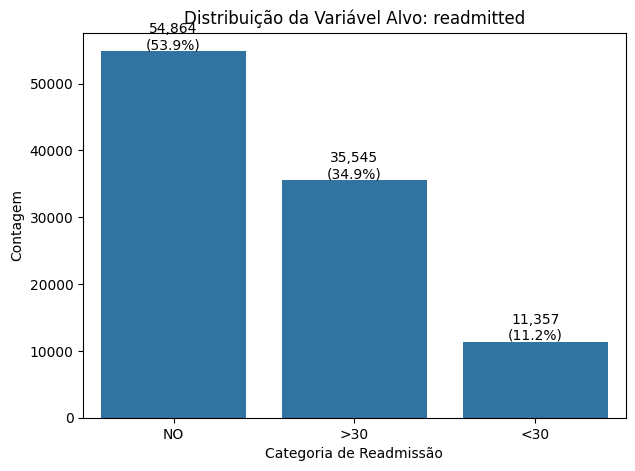

In [ ]:
# Distribuição da variável alvo: readmitted
plt.figure(figsize=(7, 5))
ordem = ['NO', '>30', '<30']
contagens = df['readmitted'].value_counts()
sns.barplot(x=contagens.index, y=contagens.values, order=ordem)
plt.title('Distribuição da Variável Alvo: readmitted')
plt.xlabel('Categoria de Readmissão')
plt.ylabel('Contagem')
for i, v in enumerate(contagens.reindex(ordem).values):
    plt.text(i, v + 300, f'{v:,}\n({v/len(df)*100:.1f}%)', ha='center', fontsize=10)
plt.show()


O gráfico revela um **desbalanceamento significativo** nas classes da variável alvo. A classe `NO` (não readmitido) representa ~54% dos dados, `>30` (readmitido após 30 dias) ~35%, e `<30` (readmitido em menos de 30 dias) apenas ~11%. Este desbalanceamento é um ponto de atenção crítico: modelos de classificação tendem a favorecer a classe majoritária, o que pode ser problemático dado que a classe `<30` é justamente a de maior risco clínico.


## Estatísticas Descritivas

Estatísticas descritivas fornecem um resumo das características numéricas, incluindo média, desvio padrão, mínimo, máximo e quartis. Vamos focar nos atributos numéricos mais relevantes do dataset.


In [ ]:
# Definição das colunas numéricas de interesse
colunas_numericas = ['time_in_hospital', 'num_lab_procedures', 'num_procedures',
                     'num_medications', 'number_outpatient', 'number_emergency',
                     'number_inpatient', 'number_diagnoses']

# Resumo estatístico completo dos atributos numéricos
resumo = df[colunas_numericas].describe().T
resumo['median']  = df[colunas_numericas].median()
resumo['mode']    = df[colunas_numericas].mode().iloc[0]
resumo['missing'] = df[colunas_numericas].isnull().sum()
resumo = resumo[['count','mean','std','min','25%','50%','75%','max','median','mode','missing']]
resumo.columns = ['N','Média','Desvio-Padrão','Mínimo','Q1','Mediana (50%)','Q3','Máximo','Mediana','Moda','Nulos']
resumo.round(2)

,N,Média,Desvio-Padrão,Mínimo,Q1,Mediana (50%),Q3,Máximo,Mediana,Moda,Nulos
time_in_hospital,101766.0,4.40,2.99,1.0,2.0,4.0,6.0,14.0,4.0,3,0
num_lab_procedures,101766.0,43.10,19.67,1.0,31.0,44.0,57.0,132.0,44.0,1,0
num_procedures,101766.0,1.34,1.71,0.0,0.0,1.0,2.0,6.0,1.0,0,0
num_medications,101766.0,16.02,8.13,1.0,10.0,15.0,20.0,81.0,15.0,13,0
number_outpatient,101766.0,0.37,1.27,0.0,0.0,0.0,0.0,42.0,0.0,0,0
number_emergency,101766.0,0.20,0.93,0.0,0.0,0.0,0.0,76.0,0.0,0,0
number_inpatient,101766.0,0.64,1.26,0.0,0.0,0.0,1.0,21.0,0.0,0,0
number_diagnoses,101766.0,7.42,1.93,1.0,6.0,8.0,9.0,16.0,8.0,9,0


**O que percebemos no resumo estatístico?**

- **`time_in_hospital`**: média de ~4,4 dias e mediana de 4, distribuição relativamente simétrica. A moda é 3 dias, indicando que internações curtas são as mais comuns.
- **`num_lab_procedures`**: alta variabilidade (desvio-padrão ~19), sugerindo grande heterogeneidade nos casos — internações complexas acumulam muito mais exames.
- **`number_outpatient`, `number_emergency`, `number_inpatient`**: médias muito baixas e medianas em 0, com grande assimetria positiva — a maioria dos pacientes não tem histórico de visitas anteriores, mas outliers com dezenas de visitas puxam a média para cima. Isso sugere que transformações logarítmicas podem ser úteis.
- **`num_medications`**: distribuição aproximadamente normal (média ~16, mediana ~15), o que é favorável para algoritmos que assumem normalidade.
- **Ausência de nulos nos numéricos**: todos os atributos numéricos estão completos — os valores faltantes estão concentrados nas colunas categóricas (codificados como `'?'`).


### Média

A média é uma medida de tendência central que representa o valor típico de um conjunto de dados. É sensível a valores extremos (outliers). No caso deste dataset, colunas como `number_outpatient`, `number_emergency` e `number_inpatient` têm médias baixas mas com grande assimetria positiva — a maioria dos pacientes não tem visitas anteriores, mas alguns têm muitas, puxando a média para cima.


In [ ]:
# Média dos atributos numéricos
df[colunas_numericas].describe().loc['mean'].round(2)


,mean
time_in_hospital,4.40
num_lab_procedures,43.10
num_procedures,1.34
num_medications,16.02
number_outpatient,0.37
number_emergency,0.20
number_inpatient,0.64
number_diagnoses,7.42


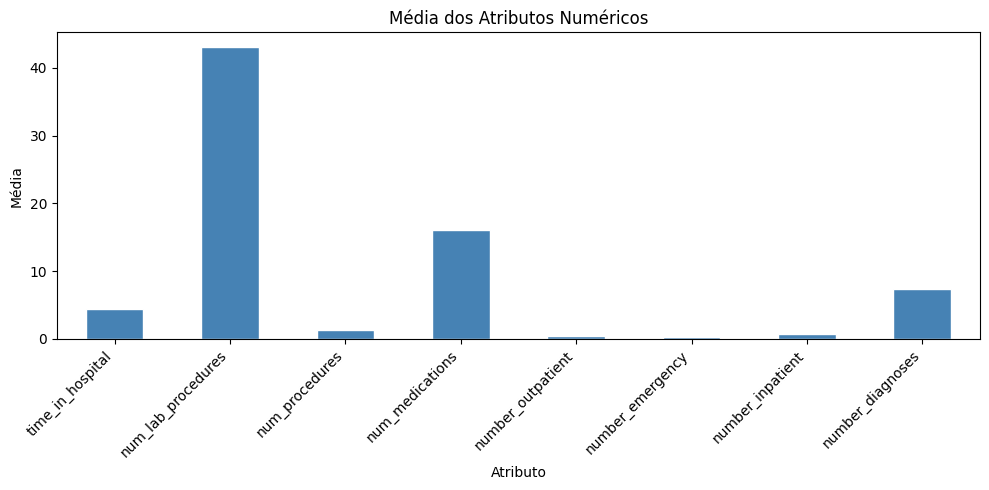

In [ ]:
# Gráfico de barras com a média de cada atributo numérico
medias = df[colunas_numericas].mean().round(2)
plt.figure(figsize=(10, 5))
medias.plot(kind='bar', color='steelblue', edgecolor='white')
plt.title('Média dos Atributos Numéricos')
plt.xlabel('Atributo')
plt.ylabel('Média')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


### Desvio Padrão

O desvio padrão mede a dispersão dos dados em torno da média. Um desvio padrão alto indica grande variabilidade. Atributos como `num_lab_procedures` possuem desvio padrão elevado (em torno de 19), indicando que o número de exames varia bastante entre os pacientes — o que pode ser um indicador clínico relevante.


In [ ]:
# Desvio padrão dos atributos numéricos
df[colunas_numericas].describe().loc['std'].round(2)


,std
time_in_hospital,2.99
num_lab_procedures,19.67
num_procedures,1.71
num_medications,8.13
number_outpatient,1.27
number_emergency,0.93
number_inpatient,1.26
number_diagnoses,1.93


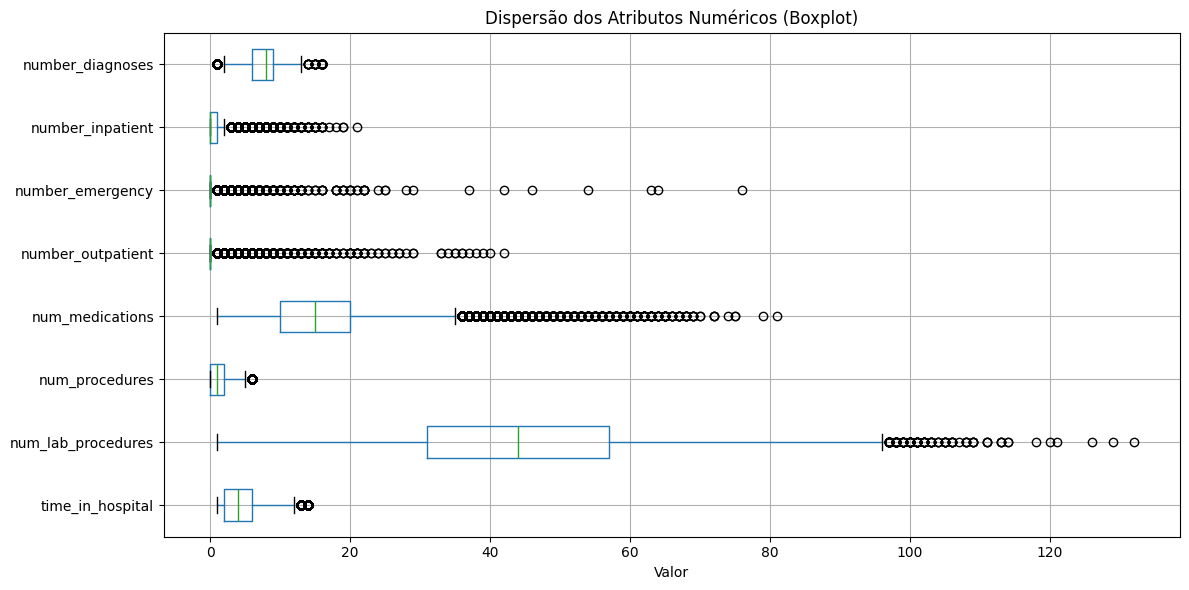

In [ ]:
# Boxplot para visualizar dispersão e outliers dos atributos numéricos
plt.figure(figsize=(12, 6))
df[colunas_numericas].boxplot(vert=False)
plt.title('Dispersão dos Atributos Numéricos (Boxplot)')
plt.xlabel('Valor')
plt.tight_layout()
plt.show()


## Histogramas

A distribuição de dados descreve como os valores de uma variável se espalham. Analisar as distribuições revela padrões, assimetrias e a possível necessidade de transformações nos dados (como normalização ou discretização).


### Tempo de Internação (`time_in_hospital`)

O tempo de internação varia de 1 a 14 dias neste dataset. É esperado que internações mais longas estejam associadas a casos mais graves, que por sua vez podem ter maior probabilidade de readmissão.


### Distribuição de todos os atributos numéricos

O checklist recomenda verificar a distribuição de **cada atributo**. Abaixo apresentamos um painel com histogramas de todos os atributos numéricos principais, o que nos dará uma visão geral antes de aprofundarmos nas mais relevantes. Observe as formas das distribuições: simétricas, assimétricas, bimodais — cada padrão sugere diferentes estratégias de pré-processamento.


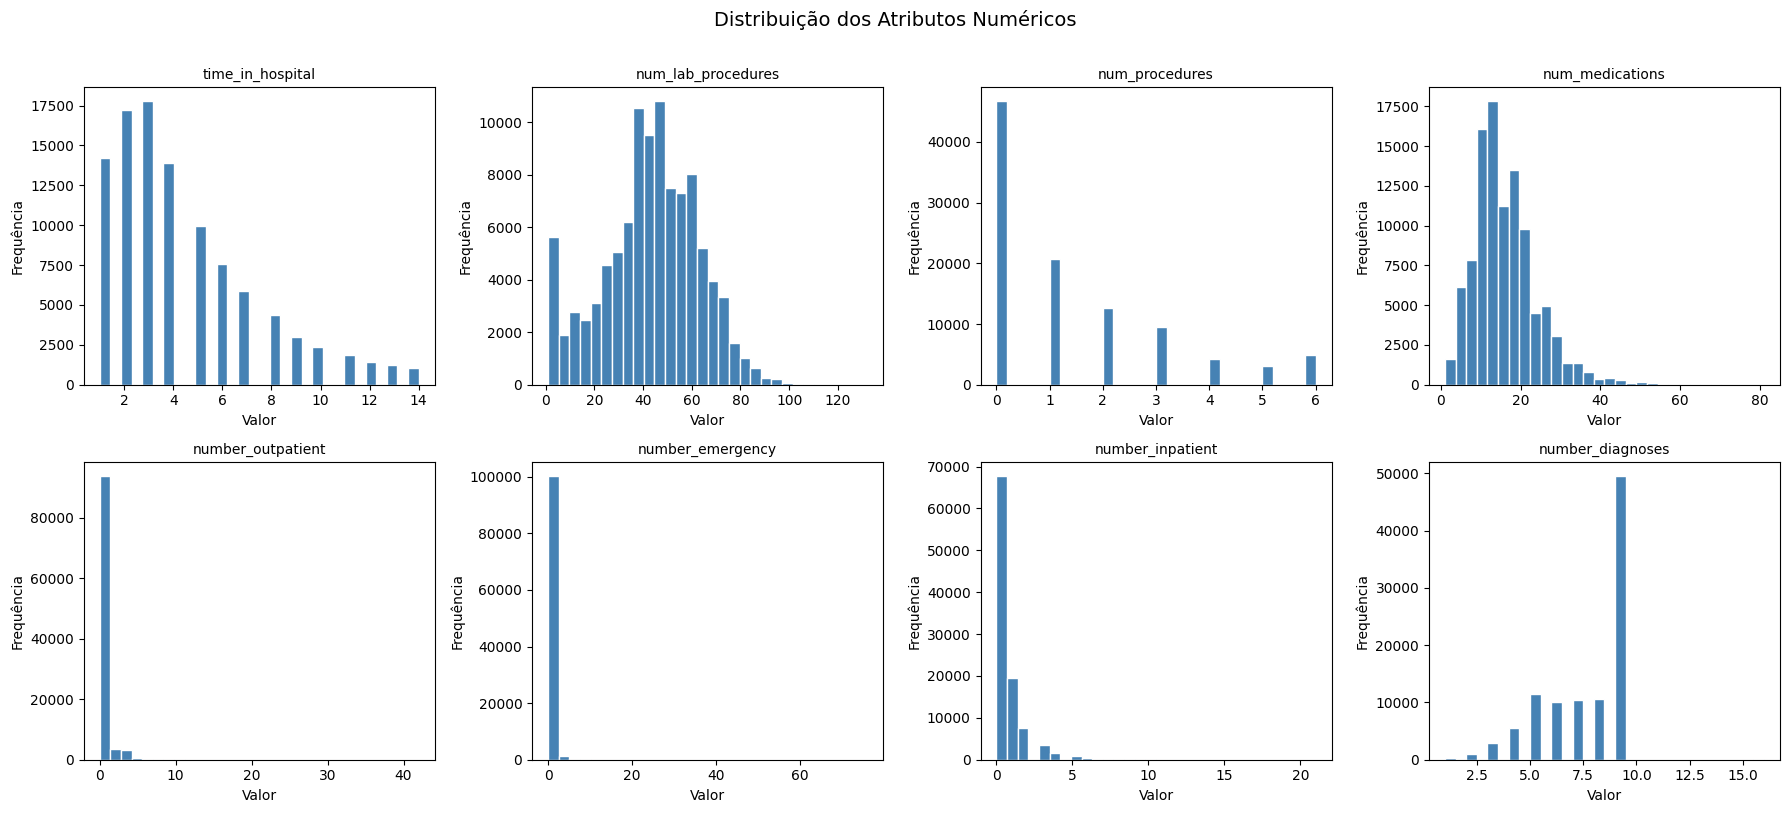

In [ ]:
# Histogramas de todos os atributos numéricos em um único painel
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.flatten()

for idx, col in enumerate(colunas_numericas):
    axes[idx].hist(df[col], bins=30, edgecolor='white', color='steelblue')
    axes[idx].set_title(col, fontsize=10)
    axes[idx].set_xlabel('Valor')
    axes[idx].set_ylabel('Frequência')

plt.suptitle('Distribuição dos Atributos Numéricos', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()


**O que o painel de histogramas revela?**

- **`time_in_hospital`**: distribuição relativamente uniforme/unimodal, com leve assimetria à direita. A maioria dos pacientes fica entre 1 e 7 dias.
- **`num_lab_procedures`**: distribuição aproximadamente normal, centrada em torno de 44 exames. Valores extremos acima de 100 indicam casos muito complexos.
- **`num_procedures`**: fortemente concentrado em 0–3 procedimentos, com assimetria positiva marcada. Candidato a discretização ou transformação logarítmica.
- **`num_medications`**: distribuição próxima da normal (média ~16), a mais adequada para algoritmos paramétricos sem transformações.
- **`number_outpatient`, `number_emergency`, `number_inpatient`**: distribuições com grande concentração em zero e cauda longa à direita — perfil típico de contagens de eventos raros. Transformação log(x+1) pode ser útil.
- **`number_diagnoses`**: distribuição bimodal com picos em torno de 5 e 9 diagnósticos, sugerindo dois perfis distintos de pacientes: casos simples e casos altamente comórbidos.


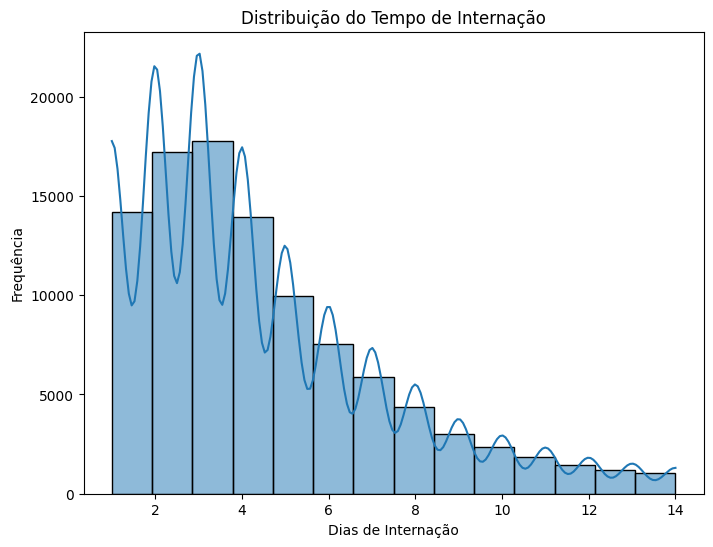

In [ ]:
plt.figure(figsize=(8, 6))
sns.histplot(df['time_in_hospital'], kde=True, bins=14)
plt.title('Distribuição do Tempo de Internação')
plt.xlabel('Dias de Internação')
plt.ylabel('Frequência')
plt.show()


O histograma mostra que a maioria dos pacientes permanece internada entre 1 e 7 dias, com uma distribuição aproximadamente unimodal e assimetria positiva leve. Há relativamente poucos pacientes com internações muito longas (próximas de 14 dias). Essa distribuição sugere que uma discretização ou transformação logarítmica pode ser útil em etapas de modelagem futuras.


### Número de Medicamentos (`num_medications`)

O número de medicamentos distintos administrados durante a internação é um indicador importante da complexidade clínica do caso. Pacientes com mais medicamentos tendem a ter condições mais graves.


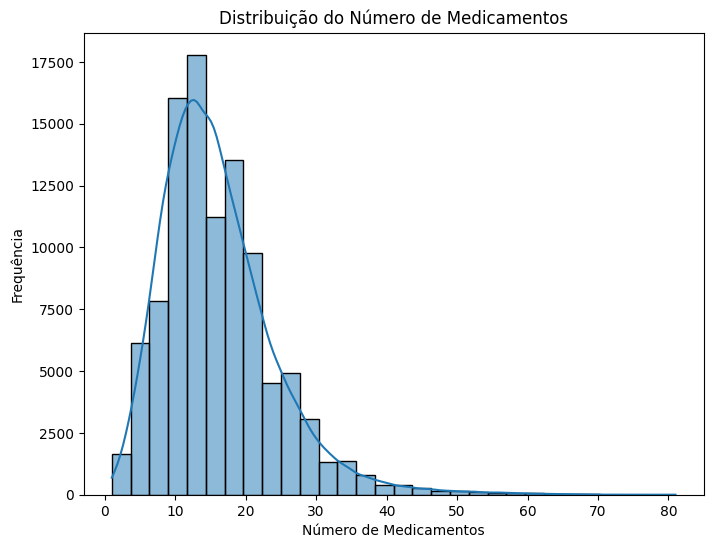

In [ ]:
plt.figure(figsize=(8, 6))
sns.histplot(df['num_medications'], kde=True, bins=30)
plt.title('Distribuição do Número de Medicamentos')
plt.xlabel('Número de Medicamentos')
plt.ylabel('Frequência')
plt.show()


A distribuição do número de medicamentos apresenta um formato aproximadamente normal, com centro em torno de 15 medicamentos. Valores extremos acima de 30 medicamentos representam casos de alta complexidade clínica. A forma da distribuição sugere que a normalização pode ser benéfica para algoritmos sensíveis à escala.


## Boxplots por Categoria de Readmissão

Para entender quais atributos diferenciam as categorias de readmissão, analisamos como os atributos numéricos se comportam quando agrupados pela variável alvo. Isso pode revelar padrões que o modelo de classificação usará para fazer suas previsões.


In [ ]:
# Estatísticas descritivas agrupadas pela variável alvo
df.groupby('readmitted')[colunas_numericas].describe().T


readmitted                       <30           >30            NO
time_in_hospital count  11357.000000  35545.000000  54864.000000
                 mean       4.768249      4.495541      4.254429
                 std        3.028165      2.988064      2.964964
                 min        1.000000      1.000000      1.000000
                 25%        2.000000      2.000000      2.000000
...                              ...           ...           ...
number_diagnoses min        1.000000      1.000000      1.000000
                 25%        6.000000      6.000000      6.000000
                 50%        9.000000      9.000000      8.000000
                 75%        9.000000      9.000000      9.000000
                 max       16.000000     16.000000     16.000000

[64 rows x 3 columns]

### `time_in_hospital` por Categoria de Readmissão


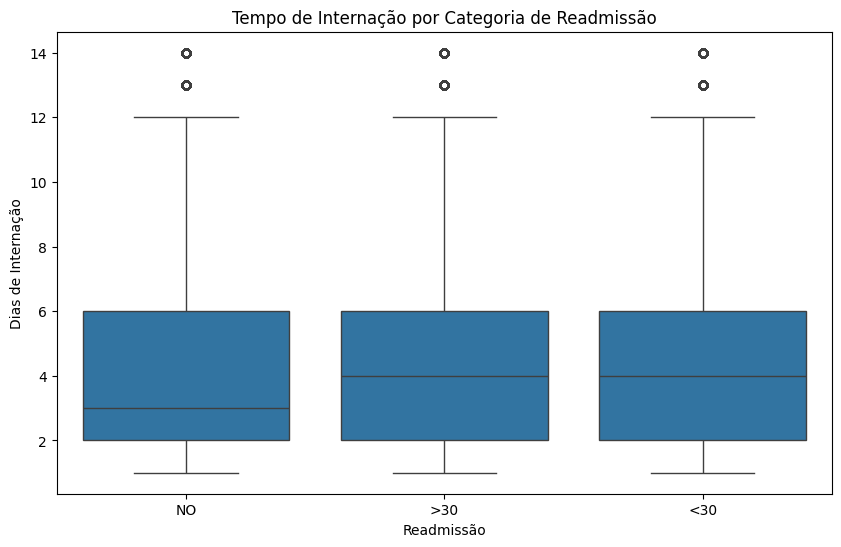

In [ ]:
plt.figure(figsize=(10, 6))
sns.boxplot(x='readmitted', y='time_in_hospital', data=df, order=['NO', '>30', '<30'])
plt.title('Tempo de Internação por Categoria de Readmissão')
plt.xlabel('Readmissão')
plt.ylabel('Dias de Internação')
plt.show()


O boxplot revela que pacientes readmitidos em menos de 30 dias (`<30`) tendem a ter medianas de tempo de internação levemente superiores às dos demais grupos, embora a sobreposição entre os grupos seja considerável. Isso sugere que o tempo de internação, isoladamente, não é um discriminador suficiente, mas pode contribuir em combinação com outras variáveis.


### `num_medications` por Categoria de Readmissão


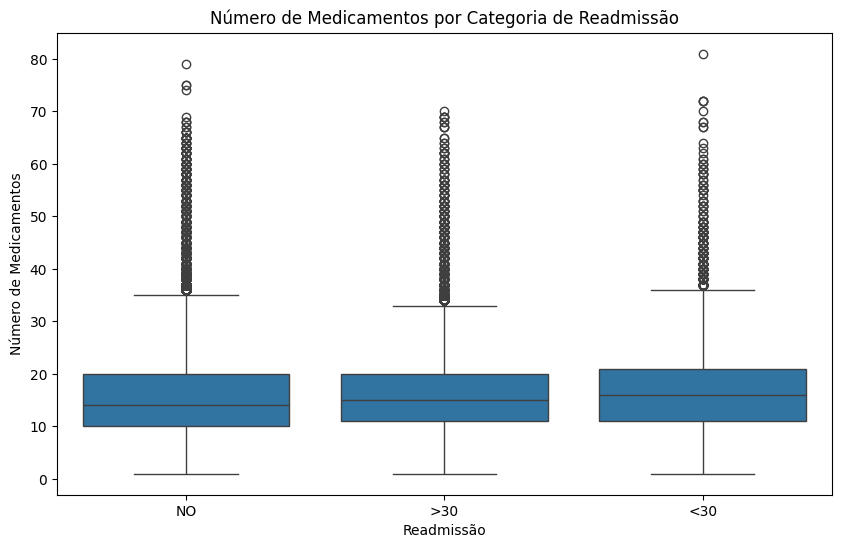

In [ ]:
plt.figure(figsize=(10, 6))
sns.boxplot(x='readmitted', y='num_medications', data=df, order=['NO', '>30', '<30'])
plt.title('Número de Medicamentos por Categoria de Readmissão')
plt.xlabel('Readmissão')
plt.ylabel('Número de Medicamentos')
plt.show()


Pacientes readmitidos (tanto `<30` quanto `>30`) apresentam mediana de número de medicamentos levemente superior aos não readmitidos. Isso é consistente com a hipótese de que pacientes com regimes medicamentosos mais complexos têm condições mais graves e maior risco de retorno ao hospital.


## Matriz de Correlação

A matriz de correlação mede a força e a direção de relações lineares entre os atributos numéricos. Valores próximos a 1 indicam forte correlação positiva, -1 forte correlação negativa, e 0 ausência de correlação linear.


In [ ]:
# Matriz de correlação entre atributos numéricos
print('\nMatriz de Correlação:')
df[colunas_numericas].corr().round(2)



Matriz de Correlação:


,time_in_hospital,num_lab_procedures,num_procedures,num_medications,number_outpatient,number_emergency,number_inpatient,number_diagnoses
time_in_hospital,1.00,0.32,0.19,0.47,-0.01,-0.01,0.07,0.22
num_lab_procedures,0.32,1.00,0.06,0.27,-0.01,-0.00,0.04,0.15
num_procedures,0.19,0.06,1.00,0.39,-0.02,-0.04,-0.07,0.07
num_medications,0.47,0.27,0.39,1.00,0.05,0.01,0.06,0.26
number_outpatient,-0.01,-0.01,-0.02,0.05,1.00,0.09,0.11,0.09
number_emergency,-0.01,-0.00,-0.04,0.01,0.09,1.00,0.27,0.06
number_inpatient,0.07,0.04,-0.07,0.06,0.11,0.27,1.00,0.10
number_diagnoses,0.22,0.15,0.07,0.26,0.09,0.06,0.10,1.00


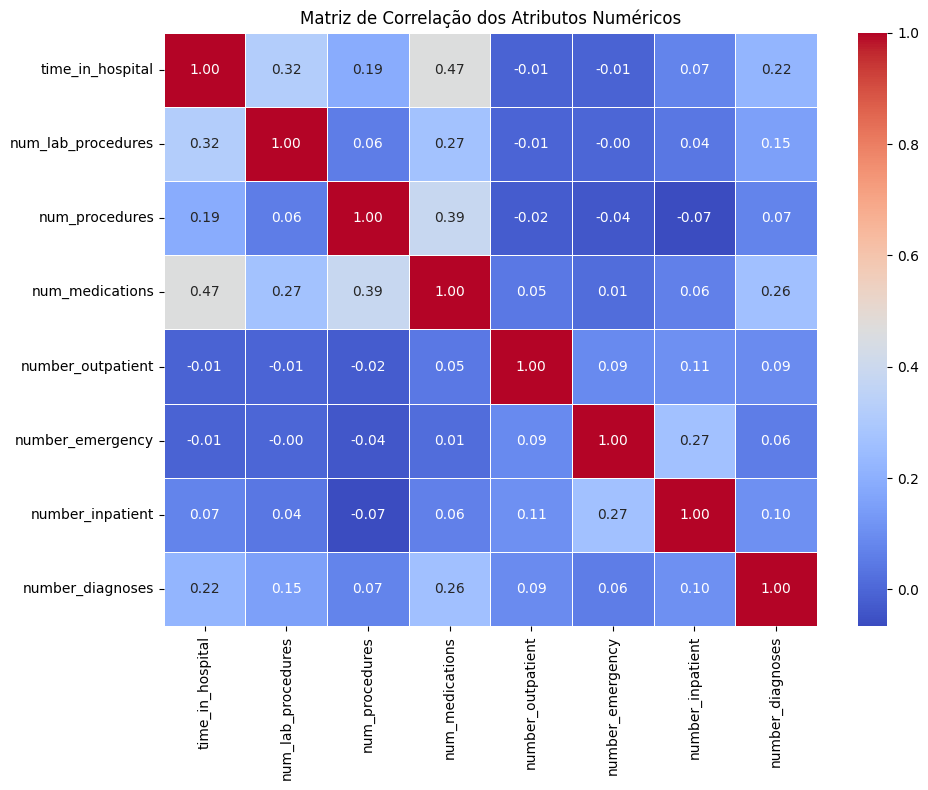

In [ ]:
plt.figure(figsize=(10, 8))
sns.heatmap(df[colunas_numericas].corr(), annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Matriz de Correlação dos Atributos Numéricos')
plt.tight_layout()
plt.show()


O mapa de calor revela que a maioria das correlações entre os atributos numéricos é fraca ou moderada, o que é um bom sinal — indica que cada variável carrega informações relativamente independentes para o modelo. A correlação mais notável é entre num_medications e time_in_hospital (0,47): pacientes internados por mais tempo tendem a receber mais medicamentos distintos, o que faz sentido clínico — internações mais longas geralmente refletem casos mais complexos. Em segundo lugar, destaca-se a correlação entre num_lab_procedures e time_in_hospital (0,32): quanto mais dias internado, mais exames laboratoriais são realizados. Por fim, num_medications e number_diagnoses também apresentam correlação moderada, confirmando que pacientes com mais diagnósticos acumulam regimes medicamentosos mais extensos.

## Tratamento de Valores Faltantes

Este dataset apresenta um padrão não convencional de valores faltantes: em vez de `NaN` padrão do pandas, as colunas categóricas utilizam o caractere `'?'` para representar dados ausentes. Além disso, as colunas `max_glu_serum` e `A1Cresult` contêm `NaN` reais. É necessário tratar ambos os casos de forma distinta.


In [ ]:
# Identificar valores codificados como '?' nas colunas categóricas
faltantes_interrogacao = (df == '?').sum()
faltantes_interrogacao = faltantes_interrogacao[faltantes_interrogacao > 0]
print('Colunas com valores "?" (valores faltantes mascarados):')
print((faltantes_interrogacao / len(df) * 100).round(2).sort_values(ascending=False).to_string())

print('\nColunas com NaN reais:')
print((df.isnull().sum()[df.isnull().sum() > 0] / len(df) * 100).round(2).sort_values(ascending=False).to_string())


Colunas com valores "?" (valores faltantes mascarados):
weight               96.86
medical_specialty    49.08
payer_code           39.56
race                  2.23
diag_3                1.40
diag_2                0.35
diag_1                0.02

Colunas com NaN reais:
max_glu_serum    94.75
A1Cresult        83.28


# Pré-Processamento de Dados

O pré-processamento de dados é uma etapa crucial para preparar os dados para modelagem. Com base na análise exploratória, identificamos as seguintes necessidades:
1. Substituir os valores `'?'` por `NaN` e tratar os faltantes
2. Descartar colunas com excesso de dados faltantes ou sem valor preditivo
3. Codificar variáveis categóricas
4. Separar features e target, dividir em treino/teste e aplicar normalização/padronização


In [ ]:
# Etapa 1: Substituir '?' por NaN nas colunas categóricas
df_proc = df.copy()
df_proc.replace('?', np.nan, inplace=True)

print('Valores faltantes após substituição de "?" por NaN:')
print((df_proc.isnull().sum()[df_proc.isnull().sum() > 0] / len(df_proc) * 100).round(2).sort_values(ascending=False).to_string())


Valores faltantes após substituição de "?" por NaN:
weight               96.86
max_glu_serum        94.75
A1Cresult            83.28
medical_specialty    49.08
payer_code           39.56
race                  2.23
diag_3                1.40
diag_2                0.35
diag_1                0.02


In [ ]:
# Etapa 2: Descartar colunas irrelevantes ou com excesso de dados faltantes
# - 'weight': 96.9% faltante → descartar
# - 'payer_code': 39.6% faltante + baixo valor preditivo → descartar
# - 'medical_specialty': 49.1% faltante → descartar
# - 'encounter_id' e 'patient_nbr': apenas identificadores → descartar
# - 'examide' e 'citoglipton': valor único ('No') → descartar

colunas_descartar = ['weight', 'payer_code', 'medical_specialty',
                      'encounter_id', 'patient_nbr', 'examide', 'citoglipton']
df_proc.drop(columns=colunas_descartar, inplace=True)

print(f'Shape após descarte de colunas: {df_proc.shape}')


Shape após descarte de colunas: (101766, 43)


In [ ]:
# Etapa 3: Tratar NaN remanescentes
# - 'race': 2.2% faltante → preencher com 'Unknown'
# - 'diag_1', 'diag_2', 'diag_3': <2% faltante → preencher com 'Unknown'
# - 'max_glu_serum', 'A1Cresult': NaN real → manter como categoria 'None' (não realizado)

df_proc['race'] = df_proc['race'].fillna('Unknown')
for col in ['diag_1', 'diag_2', 'diag_3']:
    df_proc[col] = df_proc[col].fillna('Unknown')
df_proc['max_glu_serum'] = df_proc['max_glu_serum'].fillna('None')
df_proc['A1Cresult'] = df_proc['A1Cresult'].fillna('None')

print(f'Valores nulos restantes: {df_proc.isnull().sum().sum()}')

Valores nulos restantes: 0


In [ ]:
# Etapa 4: Separar features (X) e target (y)
X = df_proc.drop('readmitted', axis=1)
y = df_proc['readmitted']

# Codificar variáveis categóricas com LabelEncoder (para fins de demonstração)
X_encoded = X.copy()
le = LabelEncoder()
for col in X_encoded.select_dtypes(include='object').columns:
    X_encoded[col] = le.fit_transform(X_encoded[col].astype(str))

print(f'Shape de X após codificação: {X_encoded.shape}')


Shape de X após codificação: (101766, 42)


In [ ]:
# Etapa 5: Dividir os dados em treino e teste (estratificado)
X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, y, test_size=0.3, random_state=42, stratify=y
)

print(f'Dimensões de X_train: {X_train.shape}')
print(f'Dimensões de X_test:  {X_test.shape}')
print(f'Dimensões de y_train: {y_train.shape}')
print(f'Dimensões de y_test:  {y_test.shape}')


Dimensões de X_train: (71236, 42)
Dimensões de X_test:  (30530, 42)
Dimensões de y_train: (71236,)
Dimensões de y_test:  (30530,)


## Normalização

A normalização escala os dados para um intervalo fixo, geralmente entre 0 e 1. É especialmente útil para algoritmos como KNN e redes neurais que são sensíveis às escalas das features. Aqui aplicamos o `MinMaxScaler`, treinado apenas nos dados de treino para evitar vazamento de informação.


In [ ]:
# Inicializar o MinMaxScaler
scaler_norm = MinMaxScaler()


In [ ]:
# Aprende min e max APENAS de X_train
scaler_norm.fit(X_train)
X_train_normalized = scaler_norm.transform(X_train)
# Aplica a mesma transformação ao X_test
X_test_normalized = scaler_norm.transform(X_test)


In [ ]:
# Exibir as primeiras linhas dos dados normalizados
df_normalized = pd.DataFrame(X_train_normalized, columns=X_train.columns)
print('\nPrimeiras 5 linhas dos dados normalizados (treino):')
df_normalized.head()



Primeiras 5 linhas dos dados normalizados (treino):


,race,gender,age,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,num_lab_procedures,num_procedures,num_medications,...,troglitazone,tolazamide,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed
0,0.4,0.5,0.666667,0.000000,0.037037,0.208333,0.153846,0.404580,0.500000,0.1125,...,0.0,0.0,0.666667,0.333333,0.0,0.0,0.0,0.0,0.0,1.0
1,0.4,0.5,0.777778,0.142857,0.185185,0.000000,0.461538,0.374046,1.000000,0.4250,...,0.0,0.0,0.333333,0.333333,0.0,0.0,0.0,0.0,1.0,1.0
2,0.4,0.0,0.777778,0.285714,0.037037,0.000000,0.461538,0.366412,0.666667,0.2375,...,0.0,0.0,1.000000,0.333333,0.0,0.0,0.0,0.0,0.0,1.0
3,0.4,0.0,0.555556,0.000000,0.000000,0.250000,0.000000,0.000000,0.166667,0.1750,...,0.0,0.0,0.333333,0.333333,0.0,0.0,0.0,0.0,1.0,1.0
4,0.4,0.0,0.888889,0.000000,0.185185,0.250000,0.384615,0.435115,0.333333,0.3125,...,0.0,0.0,0.000000,0.333333,0.0,0.0,0.0,0.0,0.0,1.0


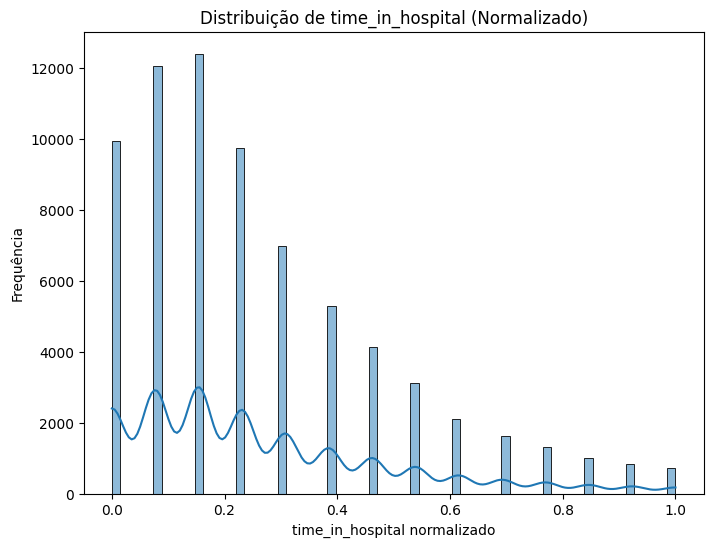

In [ ]:
# Visualização da distribuição após a normalização (time_in_hospital)
plt.figure(figsize=(8, 6))
sns.histplot(df_normalized['time_in_hospital'], kde=True)
plt.title('Distribuição de time_in_hospital (Normalizado)')
plt.xlabel('time_in_hospital normalizado')
plt.ylabel('Frequência')
plt.show()


Após a normalização, os valores de `time_in_hospital` foram escalados para o intervalo [0, 1], mantendo a forma da distribuição original. A distribuição normalizada preserva os padrões do dado original — apenas a escala foi transformada.


## Padronização

A padronização (Z-score) transforma os dados para ter média 0 e desvio padrão 1. É preferível para algoritmos como SVM, regressão logística e análise de componentes principais (PCA). O `StandardScaler` também é treinado apenas nos dados de treino.


In [ ]:
# Inicializar o StandardScaler
scaler_std = StandardScaler()


In [ ]:
# Aprende média e desvio padrão APENAS de X_train
scaler_std.fit(X_train)
X_train_standardized = scaler_std.transform(X_train)
# Aplica a mesma transformação ao X_test
X_test_standardized = scaler_std.transform(X_test)


In [ ]:
# Exibir as primeiras linhas dos dados padronizados
df_standardized = pd.DataFrame(X_train_standardized, columns=X_train.columns)
print('\nPrimeiras 5 linhas dos dados padronizados (treino):')
df_standardized.head()



Primeiras 5 linhas dos dados padronizados (treino):


,race,gender,age,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,num_lab_procedures,num_procedures,num_medications,...,troglitazone,tolazamide,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed
0,0.267833,1.076110,-0.059131,-0.707593,-0.325275,0.063328,-0.468019,0.553819,0.971800,-0.739963,...,0.0,-0.018413,0.709322,-0.082099,-0.011241,-0.003747,-0.005299,-0.003747,-1.076505,0.54601
1,0.267833,1.076110,0.568249,-0.013953,0.430629,-1.171135,0.874298,0.350347,2.730738,2.334786,...,0.0,-0.018413,-0.483278,-0.082099,-0.011241,-0.003747,-0.005299,-0.003747,0.928932,0.54601
2,0.267833,-0.928958,0.568249,0.679686,-0.325275,-1.171135,0.874298,0.299479,1.558112,0.489936,...,0.0,-0.018413,1.901923,-0.082099,-0.011241,-0.003747,-0.005299,-0.003747,-1.076505,0.54601
3,0.267833,-0.928958,-0.686511,-0.707593,-0.514252,0.310220,-1.139178,-2.142181,-0.200826,-0.125013,...,0.0,-0.018413,-0.483278,-0.082099,-0.011241,-0.003747,-0.005299,-0.003747,0.928932,0.54601
4,0.267833,-0.928958,1.195629,-0.707593,0.430629,0.310220,0.538719,0.757290,0.385487,1.227876,...,0.0,-0.018413,-1.675879,-0.082099,-0.011241,-0.003747,-0.005299,-0.003747,-1.076505,0.54601


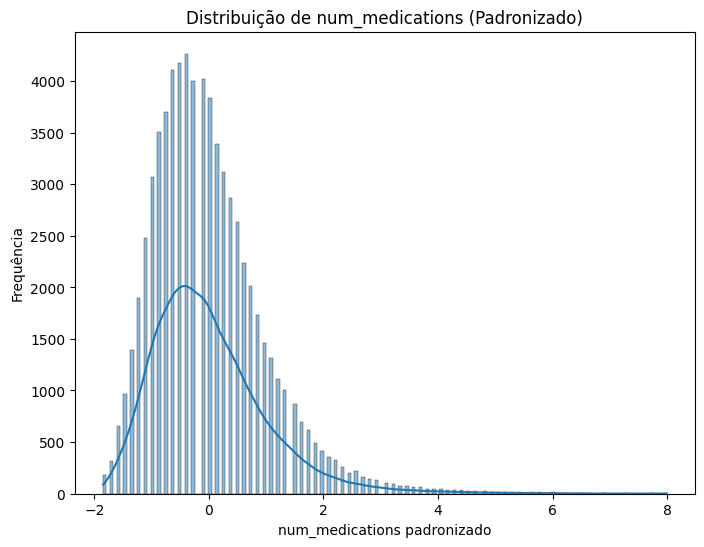

In [ ]:
# Visualização da distribuição após a padronização (num_medications)
plt.figure(figsize=(8, 6))
sns.histplot(df_standardized['num_medications'], kde=True)
plt.title('Distribuição de num_medications (Padronizado)')
plt.xlabel('num_medications padronizado')
plt.ylabel('Frequência')
plt.show()


Após a padronização, `num_medications` possui média próxima de zero e desvio padrão de 1. A forma da distribuição (aproximadamente normal) é preservada, mas agora está centrada na origem, facilitando a convergência de algoritmos sensíveis à escala.


## Outras Transformações e Etapas de Pré-Processamento

Além da normalização e padronização, implementamos aqui mais duas transformações relevantes para o dataset, gerando **visões diferentes** dos dados conforme solicitado pelo checklist:

1. **Discretização** de `time_in_hospital` em categorias clínicas significativas
2. **One-Hot Encoding** de variáveis categóricas de baixa cardinalidade (`race`, `gender`, `change`, `diabetesMed`)


Distribuição das faixas de internação:
internacao_faixa
Curta (1-3 dias)     49188
Média (4-7 dias)     37288
Longa (8-14 dias)    15290
Name: count, dtype: int64


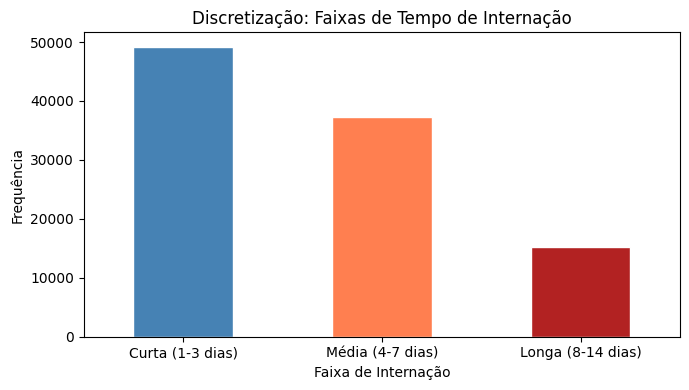

In [ ]:
# ── Transformação 1: Discretização de time_in_hospital ──────────────────
# Dividimos em 3 faixas clínicas: internação curta, média e longa
df_proc['internacao_faixa'] = pd.cut(
    df_proc['time_in_hospital'],
    bins=[0, 3, 7, 14],
    labels=['Curta (1-3 dias)', 'Média (4-7 dias)', 'Longa (8-14 dias)']
)

print('Distribuição das faixas de internação:')
print(df_proc['internacao_faixa'].value_counts())

# Visualizar a distribuição das faixas
plt.figure(figsize=(7, 4))
df_proc['internacao_faixa'].value_counts().reindex(
    ['Curta (1-3 dias)', 'Média (4-7 dias)', 'Longa (8-14 dias)']
).plot(kind='bar', color=['steelblue', 'coral', 'firebrick'], edgecolor='white')
plt.title('Discretização: Faixas de Tempo de Internação')
plt.xlabel('Faixa de Internação')
plt.ylabel('Frequência')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


A discretização de `time_in_hospital` em três faixas clínicas (curta, média e longa) facilita a interpretação e pode melhorar o desempenho de certos algoritmos. A maioria dos pacientes se concentra na faixa de internação curta (1–3 dias), seguida pela média (4–7 dias), sendo as internações longas (8–14 dias) as menos frequentes — mas provavelmente as de maior gravidade e risco de readmissão.


In [ ]:
# ── Transformação 2: One-Hot Encoding de variáveis categóricas ──────────
# Aplicamos OHE em variáveis com baixa cardinalidade e sem ordem natural
colunas_ohe = ['race', 'gender', 'change', 'diabetesMed']

df_ohe = pd.get_dummies(df_proc[colunas_ohe], drop_first=True)

print(f'Shape original das colunas categóricas selecionadas: {df_proc[colunas_ohe].shape}')
print(f'Shape após One-Hot Encoding: {df_ohe.shape}')
print('\nColunas geradas:')
print(df_ohe.columns.tolist())
print('\nPrimeiras 5 linhas:')
display(df_ohe.head())


Shape original das colunas categóricas selecionadas: (101766, 4)
Shape após One-Hot Encoding: (101766, 9)

Colunas geradas:
['race_Asian', 'race_Caucasian', 'race_Hispanic', 'race_Other', 'race_Unknown', 'gender_Male', 'gender_Unknown/Invalid', 'change_No', 'diabetesMed_Yes']

Primeiras 5 linhas:


,race_Asian,race_Caucasian,race_Hispanic,race_Other,race_Unknown,gender_Male,gender_Unknown/Invalid,change_No,diabetesMed_Yes
0,False,True,False,False,False,False,False,True,False
1,False,True,False,False,False,False,False,False,True
2,False,False,False,False,False,False,False,True,True
3,False,True,False,False,False,True,False,False,True
4,False,True,False,False,False,True,False,False,True


O One-Hot Encoding transforma variáveis categóricas em colunas binárias (0 ou 1), eliminando qualquer suposição de ordem entre as categorias — algo que o `LabelEncoder` não garante. Usamos `drop_first=True` para evitar multicolinearidade perfeita (armadilha das dummies). As 4 colunas originais geraram novas colunas binárias, prontas para uso em modelos como regressão logística, SVM e redes neurais.

**Observação:** para as colunas de diagnóstico (`diag_1`, `diag_2`, `diag_3`), com centenas de códigos ICD-9, o OHE geraria um número excessivo de colunas. A estratégia recomendada é o agrupamento em categorias clínicas (circulatório, respiratório, diabetes, etc.) antes do encoding, o que é deixado como etapa futura de refinamento.


# Respondendo Nossas Hipóteses

Com base nas análises realizadas ao longo deste notebook, retomamos as hipóteses levantadas inicialmente e as respondemos com base nos dados.


## Hipótese 1

**Pacientes com mais dias de internação têm maior probabilidade de readmissão em menos de 30 dias?**


Média de dias de internação por categoria de readmissão:
readmitted
NO     4.25
>30    4.50
<30    4.77
Name: time_in_hospital, dtype: float64


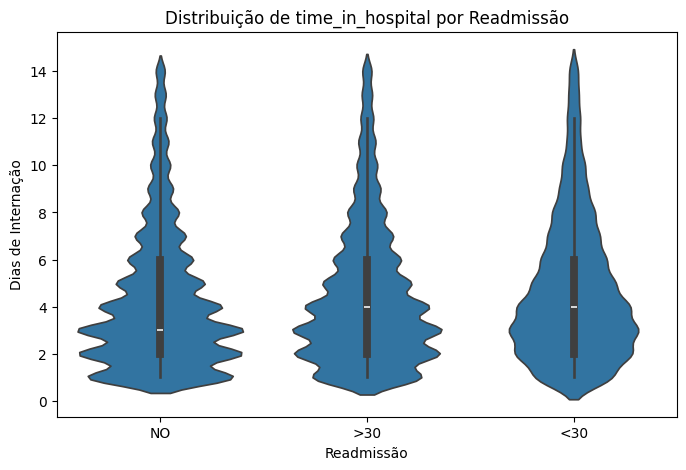


A hipótese é PARCIALMENTE CONFIRMADA: pacientes readmitidos (<30) tendem a ter médias levemente superiores de tempo de internação, mas a diferença é modesta.


In [ ]:
# Análise da hipótese 1: time_in_hospital vs readmitted
medias_por_classe = df.groupby('readmitted')['time_in_hospital'].mean().reindex(['NO', '>30', '<30'])
print('Média de dias de internação por categoria de readmissão:')
print(medias_por_classe.round(2))

plt.figure(figsize=(8, 5))
sns.violinplot(x='readmitted', y='time_in_hospital', data=df, order=['NO', '>30', '<30'])
plt.title('Distribuição de time_in_hospital por Readmissão')
plt.xlabel('Readmissão')
plt.ylabel('Dias de Internação')
plt.show()

print('\nA hipótese é PARCIALMENTE CONFIRMADA: pacientes readmitidos (<30) tendem a ter'
      ' médias levemente superiores de tempo de internação, mas a diferença é modesta.')


## Hipótese 2

**Pacientes com mais medicamentos têm maior risco de readmissão precoce?**


Média de número de medicamentos por categoria de readmissão:
readmitted
NO     15.67
>30    16.28
<30    16.90
Name: num_medications, dtype: float64


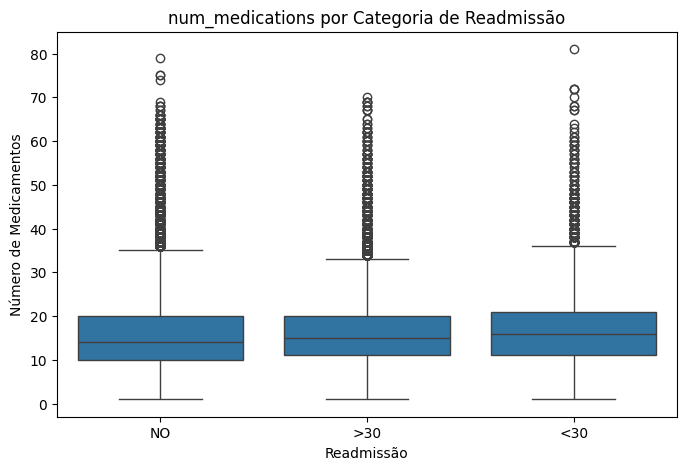


A hipótese é PARCIALMENTE CONFIRMADA: pacientes readmitidos têm, em média, mais medicamentos que os não readmitidos, consistente com maior complexidade clínica.


In [ ]:
# Análise da hipótese 2: num_medications vs readmitted
medias_med = df.groupby('readmitted')['num_medications'].mean().reindex(['NO', '>30', '<30'])
print('Média de número de medicamentos por categoria de readmissão:')
print(medias_med.round(2))

plt.figure(figsize=(8, 5))
sns.boxplot(x='readmitted', y='num_medications', data=df, order=['NO', '>30', '<30'])
plt.title('num_medications por Categoria de Readmissão')
plt.xlabel('Readmissão')
plt.ylabel('Número de Medicamentos')
plt.show()

print('\nA hipótese é PARCIALMENTE CONFIRMADA: pacientes readmitidos têm, em média,'
      ' mais medicamentos que os não readmitidos, consistente com maior complexidade clínica.')


## Hipótese 3

**Pacientes com HbA1c anormal têm taxas de readmissão precoce mais altas?**


Distribuição de readmissão por resultado do A1C (%):
readmitted     NO    >30    <30
A1Cresult                      
>7          55.85  34.10  10.05
>8          54.82  35.31   9.87
Norm        58.30  32.04   9.66


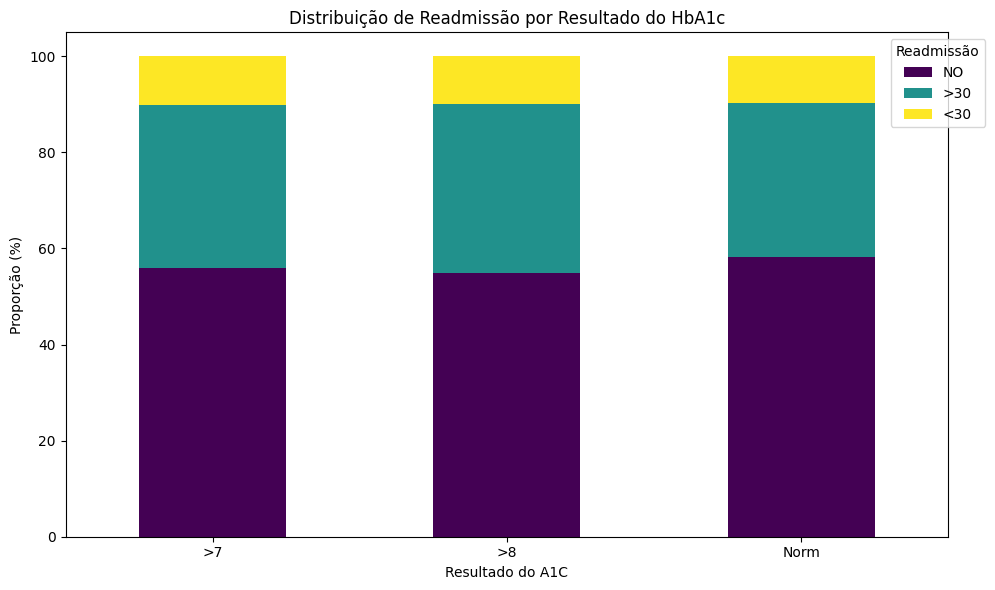


A hipótese precisa de análise mais cuidadosa: a maioria dos pacientes não tem o exame realizado (None), dificultando comparações diretas. Entre os que realizaram, resultados anormais (>7 e >8) parecem associados a taxas levemente maiores de <30.


In [ ]:
# Análise da hipótese 3: A1Cresult vs readmitted
crosstab = pd.crosstab(df['A1Cresult'], df['readmitted'], normalize='index') * 100
crosstab = crosstab.reindex(columns=['NO', '>30', '<30'])
print('Distribuição de readmissão por resultado do A1C (%):')
print(crosstab.round(2))

crosstab.plot(kind='bar', figsize=(10, 6), stacked=True, colormap='viridis')
plt.title('Distribuição de Readmissão por Resultado do HbA1c')
plt.xlabel('Resultado do A1C')
plt.ylabel('Proporção (%)')
plt.legend(title='Readmissão', bbox_to_anchor=(1.05, 1))
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

print('\nA hipótese precisa de análise mais cuidadosa: a maioria dos pacientes não tem'
      ' o exame realizado (None), dificultando comparações diretas. Entre os que realizaram,'
      ' resultados anormais (>7 e >8) parecem associados a taxas levemente maiores de <30.')


# Conclusão

A análise exploratória e o pré-processamento do dataset **Diabetes 130-US Hospitals** demonstraram a riqueza e a complexidade deste conjunto de dados clínicos.

Os principais achados foram:

1. **Desbalanceamento de classes**: A variável alvo `readmitted` apresenta distribuição assimétrica — a classe de maior interesse clínico (`<30`) representa apenas ~11% dos dados. Isso exigirá atenção especial em futuras etapas de modelagem.

2. **Valores faltantes mascarados**: Diferentemente de datasets clássicos, este usa `'?'` para representar dados ausentes. As colunas `weight` (96,9%), `medical_specialty` (49,1%) e `payer_code` (39,6%) foram descartadas por excesso de ausências.

3. **Atributos informativos**: `time_in_hospital`, `num_medications`, `number_diagnoses` e `num_lab_procedures` mostraram relações com a variável alvo e são bons candidatos para features de um modelo preditivo.

4. **Hipóteses parcialmente confirmadas**:
   - Pacientes com mais dias de internação e mais medicamentos tendem a ter taxas de readmissão levemente maiores, confirmando parcialmente as hipóteses 1 e 2.
   - A relação entre HbA1c anormal e readmissão (hipótese 3) é sugestiva, mas limitada pelo alto volume de pacientes sem o exame realizado.

5. **Pré-processamento**: O pipeline de pré-processamento incluiu substituição de `'?'` por `NaN`, descarte de colunas irrelevantes, imputação de valores faltantes, codificação de variáveis categóricas, divisão estratificada treino/teste e aplicação de normalização e padronização — etapas essenciais para qualquer algoritmo de aprendizado de máquina.
